<a id='knn'></a>
<div style="background-color:#002147; color:white; padding:10px; border-radius:5px; font-size:18px">
Modelo de Cohortes

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import dask.dataframe as dd
from datetime import datetime
%matplotlib inline

In [ ]:
# Cargar datos
transactions = pd.read_parquet('../transactions_agg.parquet') #Data sin duplicados
transactions.price = transactions.price * 50000


In [ ]:
pd.set_option('display.float_format', '{:.6f}'.format)

In [6]:
dd_transactions = dd.from_pandas(transactions[["customer_id", "price", "t_dat"]], npartitions=4)

In [7]:
#Convertir a datetime y extraer año-mes
dd_transactions["t_dat"] = dd.to_datetime(dd_transactions["t_dat"])
dd_transactions["periodo"] = dd_transactions["t_dat"].dt.to_period("M")
dd_transactions["cohort_grupo"] = dd_transactions.groupby("customer_id")["t_dat"].transform("min").dt.to_period("M")

C:\Users\wonge\AppData\Local\Temp\ipykernel_12920\2995711329.py:4: UserWarning: `meta` is not specified, inferred from partial data.
Please provide `meta` if the result is unexpected.
  Before: .transform(func)
  After:  .transform(func, meta={'x': 'f8', 'y': 'f8'}) for dataframe result
  or:     .transform(func, meta=('x', 'f8'))            for series result

  dd_transactions["cohort_grupo"] = dd_transactions.groupby("customer_id")["t_dat"].transform("min").dt.to_period("M")


In [ ]:
# Materializar el resultado 
cohort_df = dd_transactions[["customer_id", "price", "t_dat", "periodo", "cohort_grupo"]].compute()

In [9]:
print(f"DataFrame de cohort creado: {len(cohort_df):,} registros")
print(cohort_df.head())

DataFrame de cohort creado: 28,583,889 registros
                                                customer_id       price  \
21437919  a26999b79325057ec497dfeaf9c13f701c6ebd06df061e... 1694.067797   
21437920  a26999b79325057ec497dfeaf9c13f701c6ebd06df061e... 2541.525424   
21437925  a285cc46ae639ad9c4a2179c99d53a8e1563ec5bd84b67...  677.118644   
21437934  a285cc46ae639ad9c4a2179c99d53a8e1563ec5bd84b67...  846.610169   
21437942  a29b87a76693778bf2c0404303c744a6de0b260005546c... 1079.661017   

              t_dat  periodo cohort_grupo  
21437919 2020-03-30  2020-03      2019-06  
21437920 2020-03-30  2020-03      2019-06  
21437925 2020-03-30  2020-03      2018-11  
21437934 2020-03-30  2020-03      2018-11  
21437942 2020-03-30  2020-03      2018-10  


In [10]:
cohort_df.head(10)

,customer_id,price,t_dat,periodo,cohort_grupo
21437919,a26999b79325057ec497dfeaf9c13f701c6ebd06df061e...,1694.067797,2020-03-30,2020-03,2019-06
21437920,a26999b79325057ec497dfeaf9c13f701c6ebd06df061e...,2541.525424,2020-03-30,2020-03,2019-06
21437925,a285cc46ae639ad9c4a2179c99d53a8e1563ec5bd84b67...,677.118644,2020-03-30,2020-03,2018-11
21437934,a285cc46ae639ad9c4a2179c99d53a8e1563ec5bd84b67...,846.610169,2020-03-30,2020-03,2018-11
21437942,a29b87a76693778bf2c0404303c744a6de0b260005546c...,1079.661017,2020-03-30,2020-03,2018-10
21437943,a2a3fbb51d84140a0adf78a28ebe05271ffdc349d2d1e1...,1439.830508,2020-03-30,2020-03,2018-09
21437946,a2a3fbb51d84140a0adf78a28ebe05271ffdc349d2d1e1...,1694.067797,2020-03-30,2020-03,2018-09
21437947,a2a3fbb51d84140a0adf78a28ebe05271ffdc349d2d1e1...,846.610169,2020-03-30,2020-03,2018-09
21437949,a2a3fbb51d84140a0adf78a28ebe05271ffdc349d2d1e1...,1185.593220,2020-03-30,2020-03,2018-09
21437950,a2a3fbb51d84140a0adf78a28ebe05271ffdc349d2d1e1...,3388.983051,2020-03-30,2020-03,2018-09


In [ ]:
# Convertir periodo y cohort grupo a string para Power BI
cohort_df['periodo'] = cohort_df['periodo'].astype(str)
cohort_df['cohort_grupo'] = cohort_df['cohort_grupo'].astype(str)

In [ ]:
# Guardar Resultados
cohort_df.to_parquet("lakehouse/cohort_analysis_V2.parquet", 
                    engine='pyarrow', 
                    index=False)

In [12]:
cohort_df.copy()

,customer_id,price,t_dat,periodo,cohort_grupo
21437919,a26999b79325057ec497dfeaf9c13f701c6ebd06df061e...,1694.067797,2020-03-30,2020-03,2019-06
21437920,a26999b79325057ec497dfeaf9c13f701c6ebd06df061e...,2541.525424,2020-03-30,2020-03,2019-06
21437925,a285cc46ae639ad9c4a2179c99d53a8e1563ec5bd84b67...,677.118644,2020-03-30,2020-03,2018-11
21437934,a285cc46ae639ad9c4a2179c99d53a8e1563ec5bd84b67...,846.610169,2020-03-30,2020-03,2018-11
21437942,a29b87a76693778bf2c0404303c744a6de0b260005546c...,1079.661017,2020-03-30,2020-03,2018-10
...,...,...,...,...,...
21437885,a1ef31d2e3f4ab68659a1903ed25bf78681fe9785db459...,1905.932203,2020-03-30,2020-03,2020-03
21437892,a1fcf564bcfa99093bf56198923f0021f1119b9e3297ba...,2117.796610,2020-03-30,2020-03,2018-10
21437905,a22024bb1e7ebaefaef00f8a2ab9e519dd23d1553cc03e...,1755.932203,2020-03-30,2020-03,2018-09
21437910,a22929adf6b178fb0598ce32a3c225331149edd038c7e5...,719.491525,2020-03-30,2020-03,2018-11


In [13]:
import numpy as np

In [14]:
grouped = cohort_df.groupby(['cohort_grupo','periodo'])
#
cohorts = grouped.agg({'customer_id': pd.Series.nunique,
                       'price':np.sum})

cohorts.head()

C:\Users\wonge\AppData\Local\Temp\ipykernel_12920\3959526386.py:3: FutureWarning: The provided callable <function sum at 0x000002227F449DD0> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  cohorts = grouped.agg({'customer_id': pd.Series.nunique,


customer_id            price
cohort_grupo periodo                              
2018-09      2018-09       140340 887781979.661016
             2018-10        61551 547965459.322033
             2018-11        59793 532631610.169491
             2018-12        56736 447537812.711864
             2019-01        53683 458202170.338982

In [15]:
# Crear una serie que contenga el tamaño real de cada grupo de cohortes
cohort_group_size = cohorts['customer_id'].groupby(level=0).first()
cohort_group_size.head()


cohort_grupo
2018-09    140340
2018-10    212669
2018-11    138233
2018-12     89944
2019-01     68957
Freq: M, Name: customer_id, dtype: int64

In [16]:
cohorts['customer_id'].head()

cohort_grupo  periodo
2018-09       2018-09    140340
              2018-10     61551
              2018-11     59793
              2018-12     56736
              2019-01     53683
Name: customer_id, dtype: int64

In [18]:
retencion = cohorts['customer_id'].unstack(0) # matriz de retención entera

In [19]:
retencion.head()

cohort_grupo,2018-09,2018-10,2018-11,2018-12,2019-01,2019-02,2019-03,2019-04,2019-05,2019-06,...,2019-12,2020-01,2020-02,2020-03,2020-04,2020-05,2020-06,2020-07,2020-08,2020-09
periodo,,,,,,,,,,,,,,,,,,,,,
2018-09,140340.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-10,61551.000000,212669.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-11,59793.000000,76181.000000,138233.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-12,56736.000000,70927.000000,36452.000000,89944.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01,53683.000000,67367.000000,33057.000000,18960.000000,68957.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
retencionp = cohorts['customer_id'].unstack(0).divide(cohort_group_size,axis=1)

In [21]:
retencionp.head()

cohort_grupo,2018-09,2018-10,2018-11,2018-12,2019-01,2019-02,2019-03,2019-04,2019-05,2019-06,...,2019-12,2020-01,2020-02,2020-03,2020-04,2020-05,2020-06,2020-07,2020-08,2020-09
periodo,,,,,,,,,,,,,,,,,,,,,
2018-09,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-10,0.438585,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-11,0.426058,0.358214,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-12,0.404275,0.333509,0.263700,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01,0.382521,0.316769,0.239140,0.210798,1.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
datareten = retencionp.T

In [23]:
datareten.head()

periodo,2018-09,2018-10,2018-11,2018-12,2019-01,2019-02,2019-03,2019-04,2019-05,2019-06,...,2019-12,2020-01,2020-02,2020-03,2020-04,2020-05,2020-06,2020-07,2020-08,2020-09
cohort_grupo,,,,,,,,,,,,,,,,,,,,,
2018-09,1.000000,0.438585,0.426058,0.404275,0.382521,0.361843,0.379429,0.394015,0.394271,0.427041,...,0.350905,0.315569,0.303456,0.275787,0.268013,0.300648,0.365655,0.327996,0.315192,0.242953
2018-10,NaN,1.000000,0.358214,0.333509,0.316769,0.296056,0.310934,0.325802,0.330020,0.357875,...,0.292591,0.258848,0.248649,0.224349,0.217107,0.246985,0.307619,0.274299,0.259934,0.193169
2018-11,NaN,NaN,1.000000,0.263700,0.239140,0.222212,0.235682,0.246070,0.252668,0.279709,...,0.228129,0.196502,0.187813,0.167710,0.164476,0.189933,0.239147,0.213437,0.198433,0.143982
2018-12,NaN,NaN,NaN,1.000000,0.210798,0.184960,0.193910,0.204916,0.211476,0.237003,...,0.203738,0.166170,0.159032,0.139320,0.136018,0.163290,0.206395,0.186983,0.171585,0.120442
2019-01,NaN,NaN,NaN,NaN,1.000000,0.180446,0.178749,0.187523,0.192120,0.211668,...,0.165770,0.153879,0.145119,0.130313,0.133344,0.147135,0.184854,0.164711,0.155575,0.107371


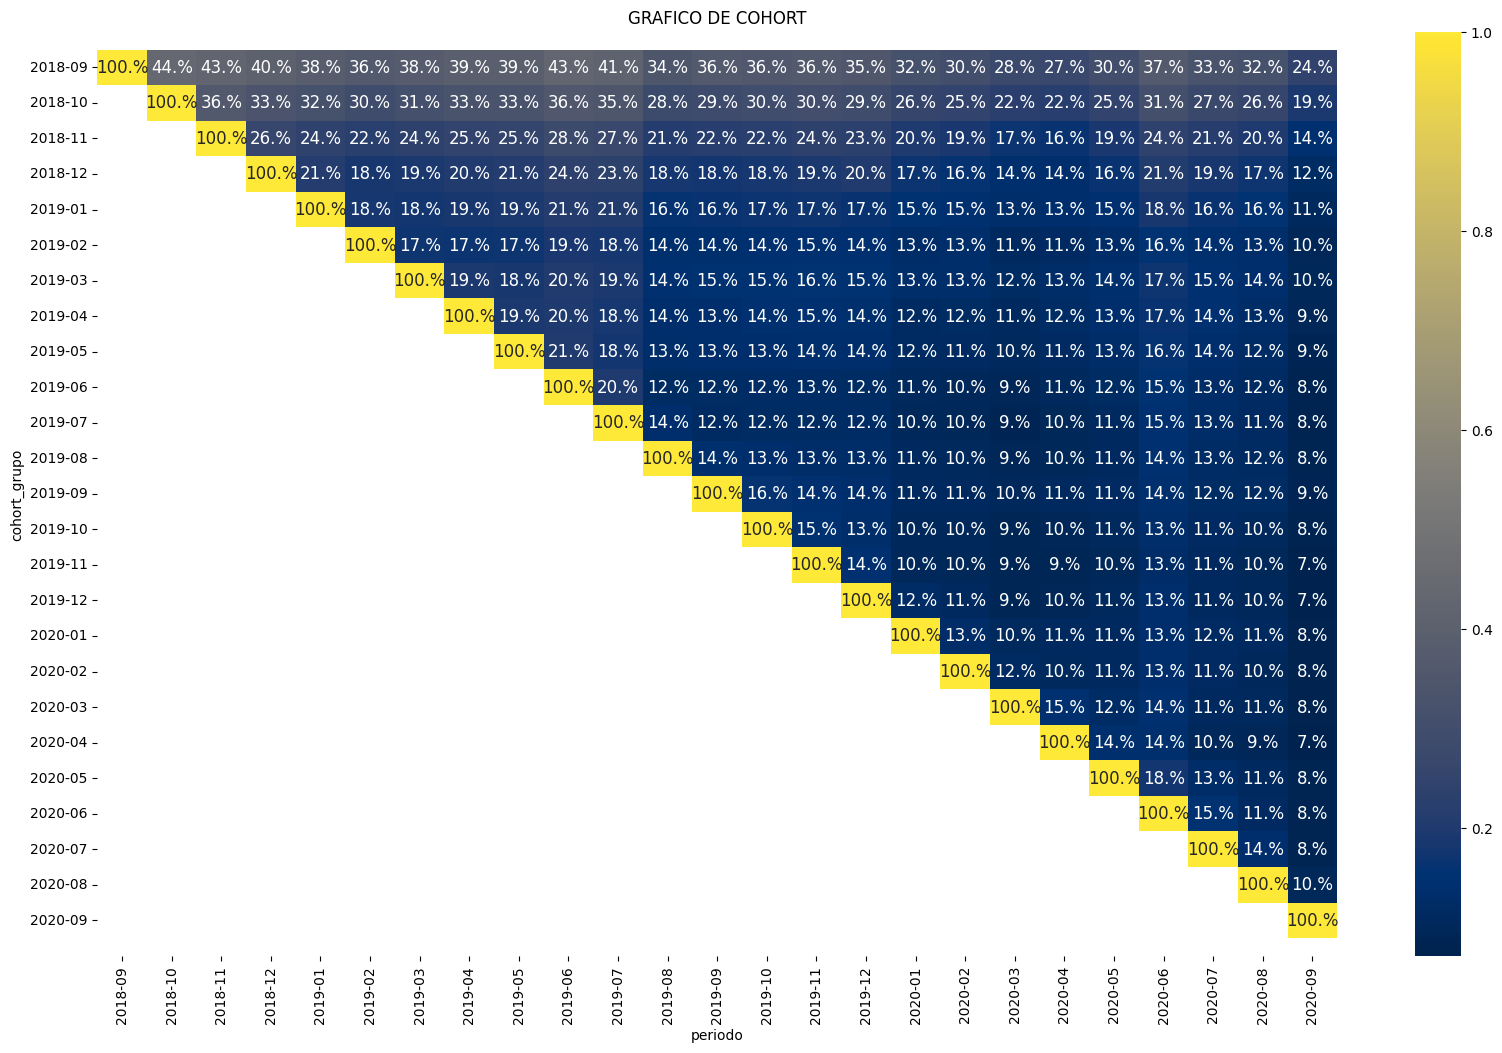

In [25]:
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(20,12))
plt.title('GRAFICO DE COHORT')
sns.heatmap(data = datareten,
            annot=True,
            fmt="#.0%",
            annot_kws={'size':12},
            cbar=True,
            cmap='cividis')

b, t = plt.ylim() # descubra los valores de bottom y top
b += 0.5 #agregue 0.5 a la parte inferior
t -= 0.5 # restra 0.5 de la parte superior
plt.ylim(b,t)
plt.show()

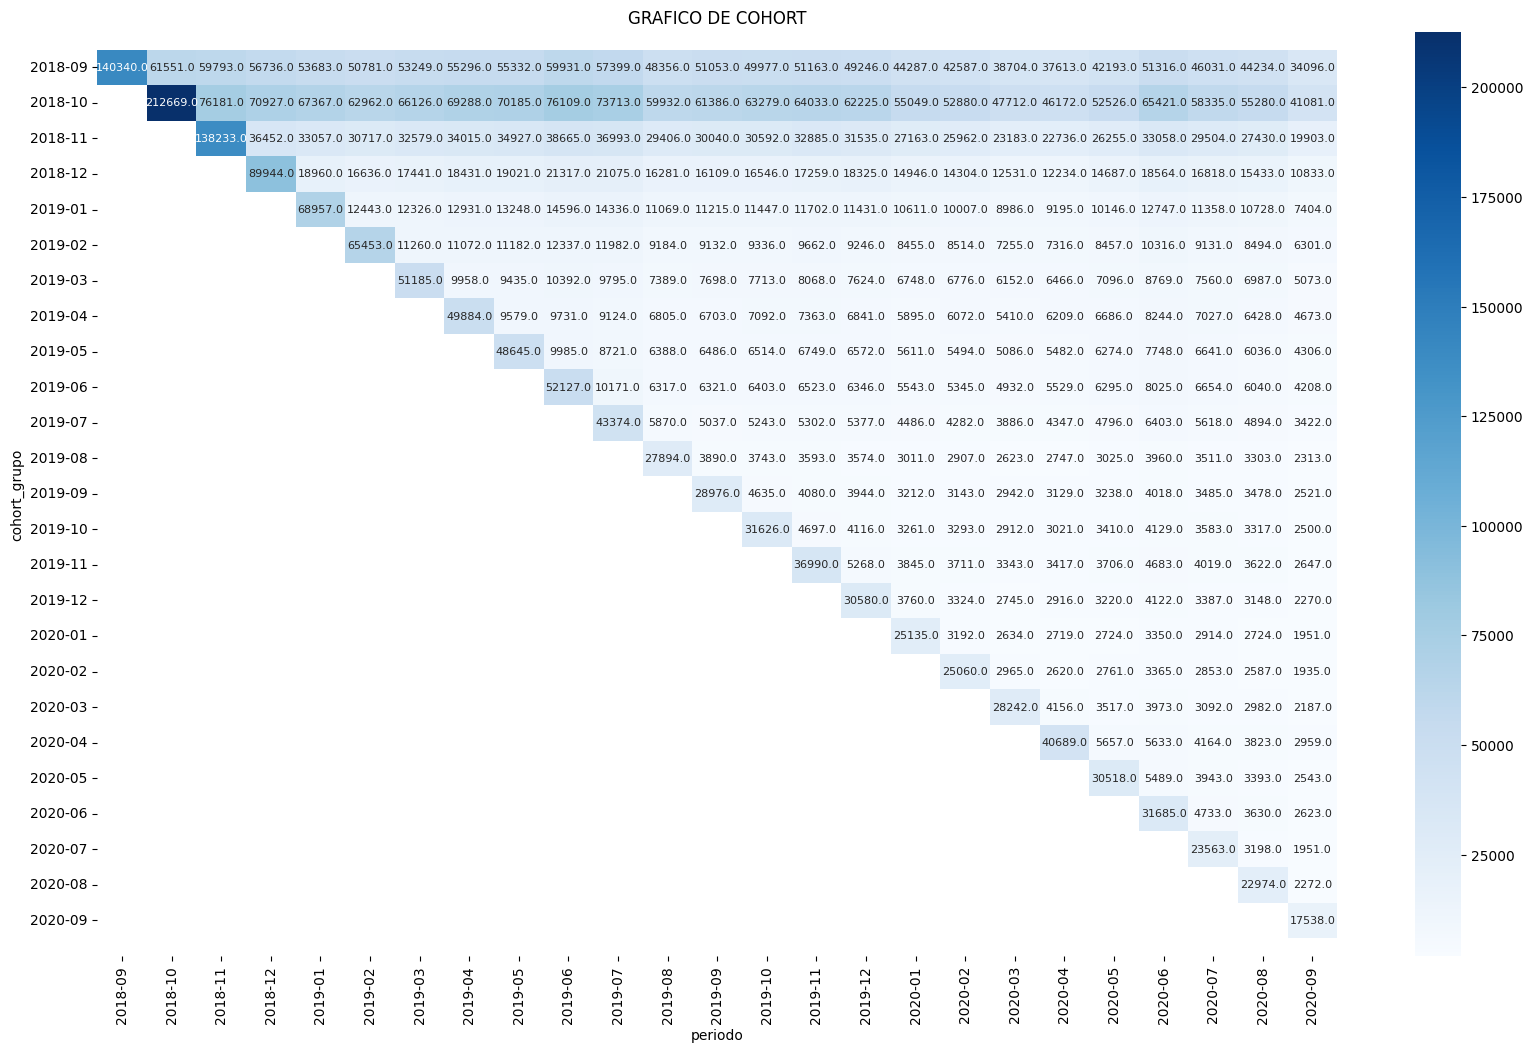

In [ ]:
# Matriz de retención entera
entero = retencion.T
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(20,12))
plt.title('GRAFICO DE COHORT')
sns.heatmap(data = entero,
            annot=True,
            fmt="",
            annot_kws={'size':8},
            cbar=True,
            cmap='Blues')

b, t = plt.ylim() # descubra los valores de bottom y top
b += 0.5 #agregue 0.5 a la parte inferior
t -= 0.5 # restra 0.5 de la parte superior
plt.ylim(b,t)
plt.show()